In [ ]:
import numpy as np
from scipy.ndimage import shift, affine_transform
from scipy.optimize import minimize
from scipy.interpolate import RBFInterpolator
import matplotlib.pyplot as plt

In [ ]:
def estimate_actuator_peaks(ifs: np.ndarray, mask: np.ndarray = None, subpixel: bool = True) -> np.ndarray:
    """Estimates (x, y) peak coordinates for each influence function in its native grid."""
    n_acts, h, w = ifs.shape
    coords = np.zeros((n_acts, 2))
    
    for i in range(n_acts):
        img = ifs[i] * (mask if mask is not None else 1.0)
        max_idx = np.unravel_index(np.argmax(img), img.shape)
        py, px = max_idx[0], max_idx[1]
        
        if subpixel and 1 <= py < h - 1 and 1 <= px < w - 1:
            # 2D quadratic sub-pixel refinement
            dx = (img[py, px + 1] - img[py, px - 1]) / (2.0 * (2.0 * img[py, px] - img[py, px + 1] - img[py, px - 1] + 1e-12))
            dy = (img[py + 1, px] - img[py - 1, px]) / (2.0 * (2.0 * img[py, px] - img[py + 1, px] - img[py - 1, px] + 1e-12))
            coords[i] = [px + np.clip(dx, -0.5, 0.5), py + np.clip(dy, -0.5, 0.5)]
        else:
            coords[i] = [float(px), float(py)]
            
    return coords


def identify_inner_actuators_radial(coords: np.ndarray, mask_shape: tuple, n_outer_rings: int = 2) -> np.ndarray:
    """
    Identifies inner actuators by computing radial distance from the grid center.
    Uses pure numpy broadcasting to estimate actuator pitch.
    """
    cy, cx = mask_shape[0] / 2.0, mask_shape[1] / 2.0
    radii = np.sqrt((coords[:, 0] - cx)**2 + (coords[:, 1] - cy)**2)
    
    # Pure numpy pitch estimation: min non-zero distance between all coordinate pairs
    diffs = coords[:, None, :] - coords[None, :, :]
    dists = np.linalg.norm(diffs, axis=-1)
    np.fill_diagonal(dists, np.inf) # Ignore self-distance
    pitch = np.median(np.min(dists, axis=1))
    
    # Define threshold: max radius minus N rings
    max_radius = np.max(radii)
    threshold_radius = max_radius - (n_outer_rings - 0.5) * pitch
    
    is_inner = radii < threshold_radius
    return is_inner


def fit_similarity_transform(src_pts: np.ndarray, dst_pts: np.ndarray):
    """Computes global similarity transformation (Scale, Rotation, Shift)."""
    src_centroid = np.mean(src_pts, axis=0)
    dst_centroid = np.mean(dst_pts, axis=0)
    
    src_centered = src_pts - src_centroid
    dst_centered = dst_pts - dst_centroid
    
    H = src_centered.T @ dst_centered
    U, S, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T
    
    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = Vt.T @ U.T
        
    scale = np.sum(S) / np.sum(src_centered**2)
    tx_ty = dst_centroid - scale * (R @ src_centroid)
    
    return scale, R, tx_ty


def apply_global_registration_to_ifs(sim_ifs: np.ndarray, scale: float, R: np.ndarray, tx_ty: np.ndarray, target_shape: tuple) -> np.ndarray:
    """Warps simulated IFs to measured grid frame, handling binning and padding automatically."""
    n_acts = len(sim_ifs)
    reg_sim_ifs = np.zeros((n_acts, *target_shape))
    
    inv_R = R.T / scale
    inv_t = -inv_R @ tx_ty
    
    for i in range(n_acts):
        reg_sim_ifs[i] = affine_transform(
            sim_ifs[i], 
            matrix=inv_R, 
            offset=inv_t[::-1],
            output_shape=target_shape, 
            order=3
        )
    return reg_sim_ifs


def apply_global_registration_to_mask(sim_mask: np.ndarray, scale: float, R: np.ndarray, tx_ty: np.ndarray, target_shape: tuple) -> np.ndarray:
    """Warps the simulated mask to the measured grid frame."""
    inv_R = R.T / scale
    inv_t = -inv_R @ tx_ty
    
    reg_mask = affine_transform(
        sim_mask.astype(float), 
        matrix=inv_R, 
        offset=inv_t[::-1],
        output_shape=target_shape, 
        order=0 
    )
    return reg_mask > 0.5


def optimize_actuator_shifts_and_gains(meas_ifs: np.ndarray, sim_ifs: np.ndarray, active_mask: np.ndarray, search_window: int = 15):
    """Finds optimal (dx, dy) shifts and peak amplitude scaling factors."""
    n_acts, h, w = sim_ifs.shape
    shifted_sim_ifs = np.copy(sim_ifs)
    gains = np.ones(n_acts)
    
    for i in range(n_acts):
        if not active_mask[i]:
            continue
            
        py, px = np.unravel_index(np.argmax(meas_ifs[i]), (h, w))
        y_min, y_max = max(0, py - search_window), min(h, py + search_window)
        x_min, x_max = max(0, px - search_window), min(w, px + search_window)
        
        meas_crop = meas_ifs[i, y_min:y_max, x_min:x_max]
        
        def loss(params):
            dx, dy, amplitude = params
            shifted_sim_crop = shift(sim_ifs[i], shift=[dy, dx], order=3)[y_min:y_max, x_min:x_max]
            res = meas_crop - amplitude * shifted_sim_crop
            return np.sum(res**2)
        
        init_amp = np.max(meas_ifs[i]) / (np.max(sim_ifs[i]) + 1e-12)
        res = minimize(loss, x0=[0.0, 0.0, init_amp], method='L-BFGS-B', bounds=[(-3, 3), (-3, 3), (0.1, 10.0)])
        
        dx_opt, dy_opt, amp_opt = res.x
        gains[i] = amp_opt
        shifted_sim_ifs[i] = shift(sim_ifs[i], shift=[dy_opt, dx_opt], order=3)
        
    return shifted_sim_ifs, gains


def extend_measured_ifs_tps(meas_ifs: np.ndarray, meas_mask: np.ndarray, target_mask: np.ndarray) -> np.ndarray:
    """Extends measured IFs up to target_mask using Thin Plate Spline fit."""
    n_acts, h, w = meas_ifs.shape
    extended_meas_ifs = np.copy(meas_ifs)
    
    y_grid, x_grid = np.mgrid[0:h, 0:w]
    valid_pts = np.column_stack((x_grid[meas_mask > 0], y_grid[meas_mask > 0]))
    eval_pts = np.column_stack((x_grid[target_mask > 0], y_grid[target_mask > 0]))
    
    fit_pts = valid_pts
    if len(valid_pts) > 1000:
        sub_idx = np.random.choice(len(valid_pts), size=1000, replace=False)
        fit_pts = valid_pts[sub_idx]

    for i in range(n_acts):
        values = meas_ifs[i][fit_pts[:, 1], fit_pts[:, 0]]
        tps = RBFInterpolator(fit_pts, values, kernel='thin_plate_spline', smoothing=1e-3)
        extrapolated_vals = tps(eval_pts)
        extended_meas_ifs[i, target_mask > 0] = extrapolated_vals
        
    return extended_meas_ifs


def plot_ifs_cubed_sum(meas_cube: np.ndarray, sim_cube: np.ndarray, pupil_center: tuple, pupil_radius: float, stage_title: str):
    """Plots the sum of the cubes of the IFs with the original measured pupil outline."""
    print(f"Generating plot: {stage_title}...")
    
    # Sum of cubes sharply isolates the actuator peaks
    sum_meas = np.sum(meas_cube**3, axis=0)
    sum_sim = np.sum(sim_cube**3, axis=0)
    
    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    
    im0 = axes[0].imshow(sum_meas, cmap='viridis', origin='lower')
    axes[0].set_title(f"Measured IFs (Sum of Cubes)\n[{stage_title}]")
    axes[0].axis('off')
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
    
    im1 = axes[1].imshow(sum_sim, cmap='viridis', origin='lower')
    axes[1].set_title(f"Simulated IFs (Sum of Cubes)\n[{stage_title}]")
    axes[1].axis('off')
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    
    # Overlay dashed outer rim of the original measured pupil on both axes
    for ax in axes:
        circle = plt.Circle(pupil_center, pupil_radius, color='red', fill=False, linestyle='--', linewidth=1.5, alpha=0.9, label='Orig. Meas. Pupil Rim')
        ax.add_patch(circle)
        ax.legend(loc='upper right')
        
    plt.tight_layout()
    plt.show()


def register_ao_influence_functions(
    meas_ifs: np.ndarray, 
    meas_mask: np.ndarray, 
    sim_ifs: np.ndarray, 
    sim_mask: np.ndarray,
    n_outer_rings: int = 2,
    show_plots: bool = True
):
    print("\n--- Starting AO Influence Function Registration ---")
    
    # Determine the center and radius of the original measured pupil for plotting
    meas_cy, meas_cx = meas_mask.shape[0] / 2.0, meas_mask.shape[1] / 2.0
    orig_pupil_center = (meas_cx, meas_cy)
    y_idx, x_idx = np.where(meas_mask > 0)
    if len(y_idx) > 0:
        orig_pupil_radius = np.max(np.sqrt((x_idx - meas_cx)**2 + (y_idx - meas_cy)**2))
    else:
        orig_pupil_radius = 0
    
    print("1. Estimating actuator peak positions on native grids...")
    coords_meas = estimate_actuator_peaks(meas_ifs, meas_mask)
    coords_sim = estimate_actuator_peaks(sim_ifs, sim_mask)
    
    print(f"2. Identifying inner actuators (excluding outer {n_outer_rings} ring(s))...")
    inner_mask = identify_inner_actuators_radial(coords_sim, mask_shape=sim_mask.shape, n_outer_rings=n_outer_rings)
    
    print("3. Computing global similarity transform (Scale, Rotation, Shift)...")
    scale, R, tx_ty = fit_similarity_transform(coords_sim[inner_mask], coords_meas[inner_mask])
    
    print("4. Resampling/Padding simulated IFs and Mask into Measured coordinates...")
    target_shape = meas_ifs.shape[1:]
    sim_ifs_registered = apply_global_registration_to_ifs(sim_ifs, scale, R, tx_ty, target_shape)
    sim_mask_registered = apply_global_registration_to_mask(sim_mask, scale, R, tx_ty, target_shape)
    
    if show_plots:
        plot_ifs_cubed_sum(meas_ifs, sim_ifs_registered, orig_pupil_center, orig_pupil_radius, stage_title="Post Global Registration")
    
    print("5. Optimizing local sub-pixel shifts and gains for INNER actuators...")
    sim_ifs_registered, gains = optimize_actuator_shifts_and_gains(
        meas_ifs, sim_ifs_registered, active_mask=inner_mask
    )
    
    print("6. Extending measured IFs pupil via Thin Plate Spline (TPS)...")
    meas_ifs_extended = extend_measured_ifs_tps(meas_ifs, meas_mask, sim_mask_registered)
    
    print("7. Optimizing local sub-pixel shifts and gains for OUTER actuators...")
    outer_mask = ~inner_mask
    sim_ifs_registered, gains_outer = optimize_actuator_shifts_and_gains(
        meas_ifs_extended, sim_ifs_registered, active_mask=outer_mask
    )
    gains[outer_mask] = gains_outer[outer_mask]
    
    print("--- Registration Complete! ---\n")
    
    if show_plots:
        plot_ifs_cubed_sum(meas_ifs_extended, sim_ifs_registered, orig_pupil_center, orig_pupil_radius, stage_title="Final (Locally Optimized & Extended)")
        
    return meas_ifs_extended, sim_ifs_registered, gains


In [ ]:
def reshape3d(ifs,mask):
    mask2use = mask.astype(bool).copy()
    ifs2use = ifs.copy()

    if ifs.shape[0] > ifs.shape[1]:
        ifs2use = ifs.T

    if np.sum(mask) < ifs.shape[1]:
        mask2use = (1-mask).astype(bool)

    nActs = np.shape(ifs2use)[0]
    ifs3d = np.zeros([nActs,mask.shape[0],mask.shape[1]])
    for j in range(nActs):
        img = np.zeros(mask.shape).fletten()
        img[mask2use.flatten()] = ifs2use[j]
        ifs3d[j] = img.reshape(mask.shape)

    return ifs3d, mask2use

In [ ]:

def register_ao_influence_functions(
    meas_ifs_flattened: np.ndarray, 
    meas_mask: np.ndarray, 
    sim_ifs_flattened: np.ndarray, 
    sim_mask: np.ndarray,
    n_outer_rings: int = 2,
    show_plots: bool = True
):
    print("\n--- Starting AO Influence Function Registration ---")

    meas_ifs, meas_mask = reshape3d(meas_ifs_flattened, meas_mask)
    sim_ifs, sim_mask = reshape3d(sim_ifs_flattened, sim_mask)
    
    print("1. Estimating actuator peak positions...")
    coords_meas = estimate_actuator_peaks(meas_ifs, meas_mask)
    coords_sim = estimate_actuator_peaks(sim_ifs, sim_mask)
    
    print(f"2. Identifying inner actuators (excluding outer {n_outer_rings} ring(s))...")
    mask_shape = meas_mask.shape
    inner_mask = identify_inner_actuators_radial(coords_sim, mask_shape, n_outer_rings=n_outer_rings)
    
    print("3. Computing global similarity transform (Scale, Rotation, Shift)...")
    scale, R, tx_ty = fit_similarity_transform(coords_sim[inner_mask], coords_meas[inner_mask])
    print(f" -> Scale: {scale:.4f}, Shift (dx, dy): {tx_ty}")
    
    print("4. Applying global registration to simulated IFs...")
    sim_ifs_registered = apply_global_registration_to_ifs(
        sim_ifs, scale, R, tx_ty, target_shape=meas_ifs.shape[1:]
    )

    plt.figure()
    
    print("5. Optimizing local sub-pixel shifts and gains for INNER actuators...")
    sim_ifs_registered, gains = optimize_actuator_shifts_and_gains(
        meas_ifs, sim_ifs_registered, active_mask=inner_mask
    )
    
    print("6. Extending measured IFs pupil via Thin Plate Spline (TPS)...")
    meas_ifs_extended = extend_measured_ifs_tps(meas_ifs, meas_mask, sim_mask)
    
    print("7. Optimizing local sub-pixel shifts and gains for OUTER actuators...")
    outer_mask = ~inner_mask
    sim_ifs_registered, gains_outer = optimize_actuator_shifts_and_gains(
        meas_ifs_extended, sim_ifs_registered, active_mask=outer_mask
    )
    gains[outer_mask] = gains_outer[outer_mask]
    
    print("--- Registration Complete! ---\n")
    
    if show_plots:
        plot_registered_ifs(meas_ifs_extended, sim_ifs_registered)
        
    return meas_ifs_extended, sim_ifs_registered, gains

In [34]:
from astropy.io import fits

# Simulated IFs
sim_iffs = fits.getdata('/raid1/mmenessini/calibration/EKARUS/ifunc/dm468_367pix_ifunc.fits')
sim_mask = fits.getdata('/raid1/mmenessini/calibration/EKARUS/pupilstop/dm468_367pix_pupil.fits')

# Measured IFs
meas_iffs = fits.getdata('/raid1/mmenessini/calibration/EKARUS/data/reordered_DM468_iffs.fits')
meas_mask = (fits.getdata('/raid1/mmenessini/calibration/EKARUS/pupilstop/reordered_DM468_367pixels.fits')).astype(bool)

In [35]:
meas_ifs2d, meas_mask = reshape3d(meas_iffs, meas_mask)
sim_ifs2d, sim_mask = reshape3d(sim_iffs, sim_mask)
sim_iffs_flip = np.zeros_like(sim_iffs)
for i in range(len(sim_ifs2d)):
    sim_iffs_flip[:,i] = np.flipud(sim_ifs2d[i])[sim_mask]

sim_ifs2d_flip, sim_mask = reshape3d(sim_iffs_flip, sim_mask)

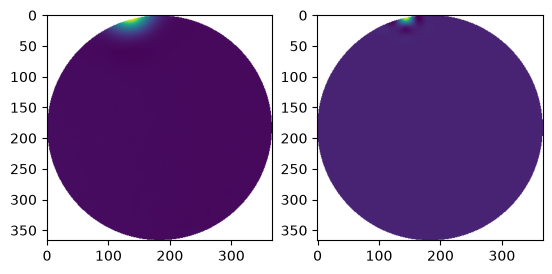

In [37]:
plt.figure()
plt.subplot(1,2,1)
plt.imshow(np.ma.masked_array(meas_ifs2d[1],mask=1-meas_mask))
plt.subplot(1,2,2)
# plt.imshow(sim_ifs2d[1])
plt.imshow(np.ma.masked_array(sim_ifs2d_flip[1],mask=1-sim_mask))

In [ ]:
register_ao_influence_functions(meas_iffs,meas_mask,sim_iffs,sim_mask)


--- Starting AO Influence Function Registration ---
1. Estimating actuator peak positions...
2. Identifying inner actuators (excluding outer 2 ring(s))...
3. Computing global similarity transform (Scale, Rotation, Shift)...
 -> Scale: 1.0539, Shift (dx, dy): [ 89.6049826  -74.65766093]
4. Applying global registration to simulated IFs...
5. Optimizing local sub-pixel shifts and gains for INNER actuators...
6. Extending measured IFs pupil via Thin Plate Spline (TPS)...
